Sube tu archivo CSV


Saving Train.csv to Train (1).csv
Dimensiones: (7000, 24)


,Employee_ID,Gender,Age,Education_Level,Relationship_Status,Hometown,Unit,Decision_skill_possess,Time_of_service,Time_since_promotion,...,Compensation_and_Benefits,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate
0,EID_23371,F,42.0,4,Married,Franklin,IT,Conceptual,4.0,4,...,type2,3.0,4,0.7516,1.8688,2.0,4,5,3,0.1841
1,EID_18000,M,24.0,3,Single,Springfield,Logistics,Analytical,5.0,4,...,type2,4.0,3,-0.9612,-0.4537,2.0,3,5,3,0.0670
2,EID_3891,F,58.0,3,Married,Clinton,Quality,Conceptual,27.0,3,...,type2,1.0,4,-0.9612,-0.4537,3.0,3,8,3,0.0851
3,EID_17492,F,26.0,3,Single,Lebanon,Human Resource Management,Behavioral,4.0,3,...,type2,1.0,3,-1.8176,-0.4537,NaN,3,7,3,0.0668
4,EID_22534,F,31.0,1,Married,Springfield,Logistics,Conceptual,5.0,4,...,type3,3.0,1,0.7516,-0.4537,2.0,2,8,2,0.1827


Numéricas: ['Age', 'Education_Level', 'Time_of_service', 'Time_since_promotion', 'growth_rate', 'Travel_Rate', 'Post_Level', 'Pay_Scale', 'Work_Life_balance', 'VAR1', 'VAR2', 'VAR3', 'VAR4', 'VAR5', 'VAR6', 'VAR7', 'Attrition_rate']
Categóricas: ['Gender', 'Relationship_Status', 'Hometown', 'Unit', 'Decision_skill_possess', 'Compensation_and_Benefits']
Datos transformados: (7000, 41)


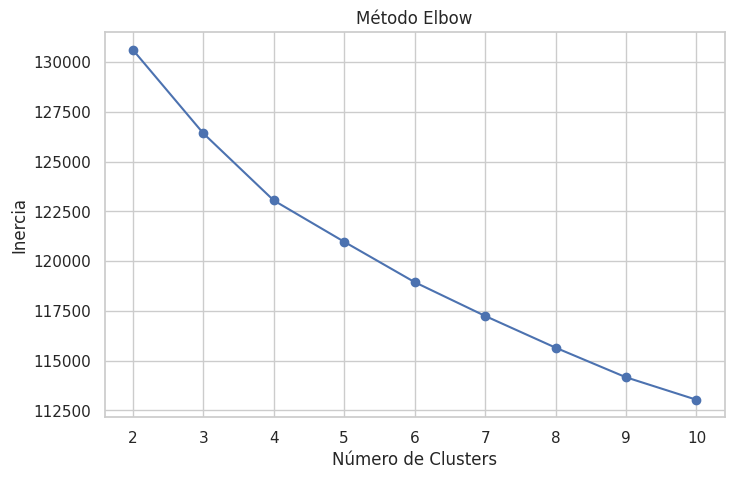

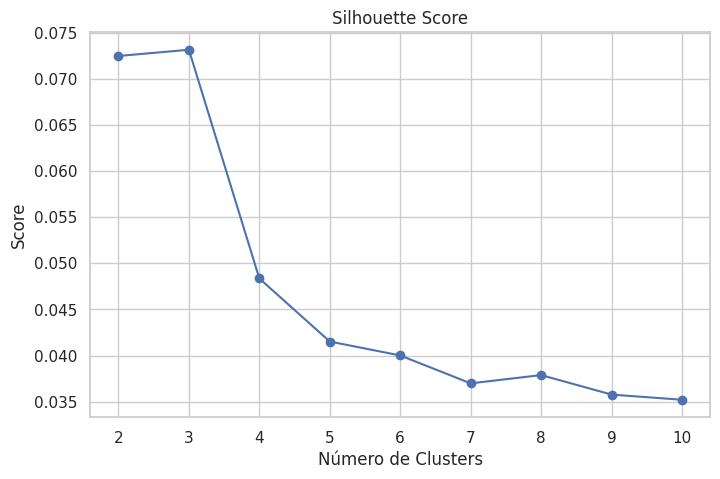

Número óptimo de clusters: 3


,Gender,Age,Education_Level,Relationship_Status,Hometown,Unit,Decision_skill_possess,Time_of_service,Time_since_promotion,growth_rate,...,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate,Cluster
0,F,42.0,4,Married,Franklin,IT,Conceptual,4.0,4,33,...,3.0,4,0.7516,1.8688,2.0,4,5,3,0.1841,2
1,M,24.0,3,Single,Springfield,Logistics,Analytical,5.0,4,36,...,4.0,3,-0.9612,-0.4537,2.0,3,5,3,0.0670,2
2,F,58.0,3,Married,Clinton,Quality,Conceptual,27.0,3,51,...,1.0,4,-0.9612,-0.4537,3.0,3,8,3,0.0851,1
3,F,26.0,3,Single,Lebanon,Human Resource Management,Behavioral,4.0,3,56,...,1.0,3,-1.8176,-0.4537,NaN,3,7,3,0.0668,2
4,F,31.0,1,Married,Springfield,Logistics,Conceptual,5.0,4,62,...,3.0,1,0.7516,-0.4537,2.0,2,8,2,0.1827,2


,Age,Education_Level,Time_of_service,Time_since_promotion,growth_rate,Travel_Rate,Post_Level,Pay_Scale,Work_Life_balance,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6,VAR7,Attrition_rate
Cluster,,,,,,,,,,,,,,,,,
0,37.925743,3.159126,11.760905,2.422777,47.700468,0.786271,2.845554,5.867188,2.478125,3.131045,-0.091686,-0.009872,1.874576,2.809672,7.085803,3.176287,0.675699
1,54.235270,3.161782,24.584829,2.522682,46.749498,0.821357,2.800482,6.065514,2.395498,3.116419,0.011819,0.004066,1.896156,2.844239,7.119631,3.278202,0.143224
2,30.166342,3.209411,6.395244,2.257756,47.161582,0.820838,2.788521,5.991199,2.368039,3.081696,-0.007118,-0.025607,1.890576,2.831696,7.092037,3.256722,0.138505


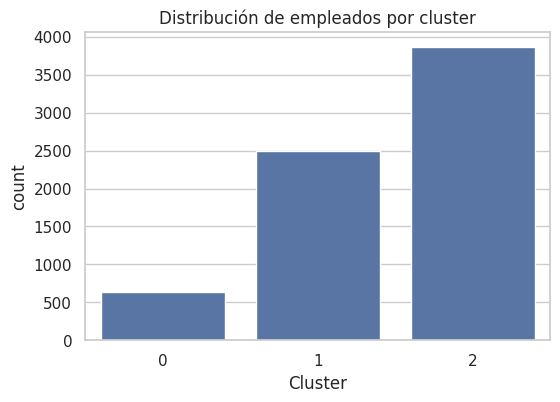

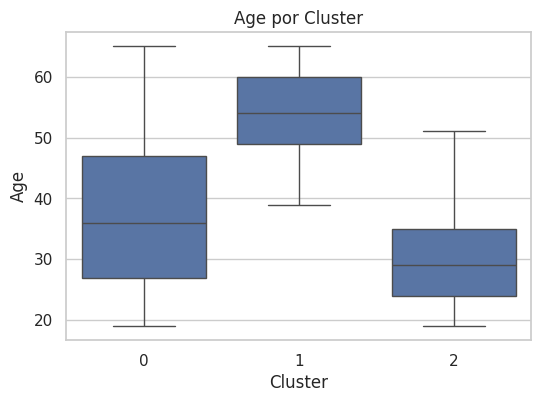

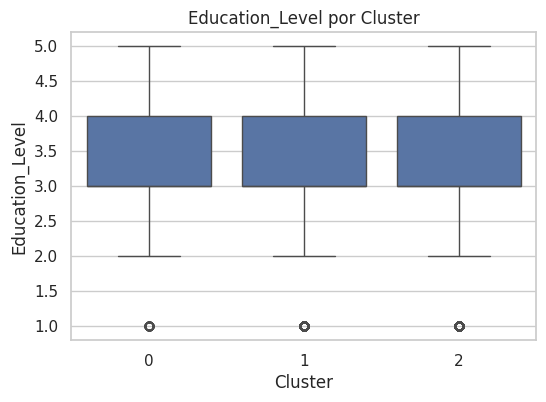

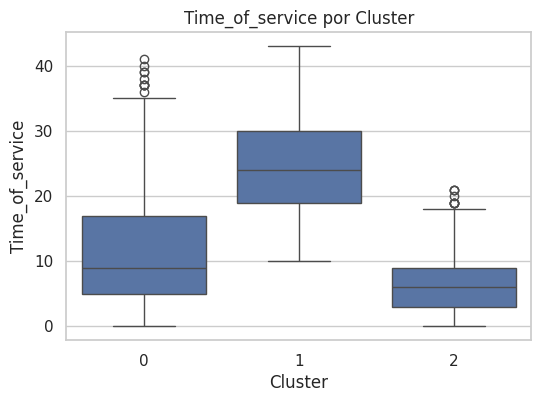

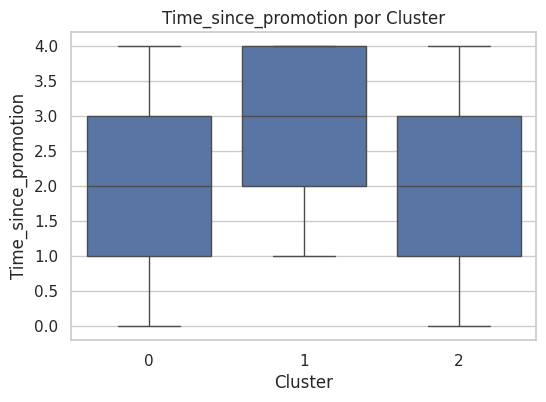

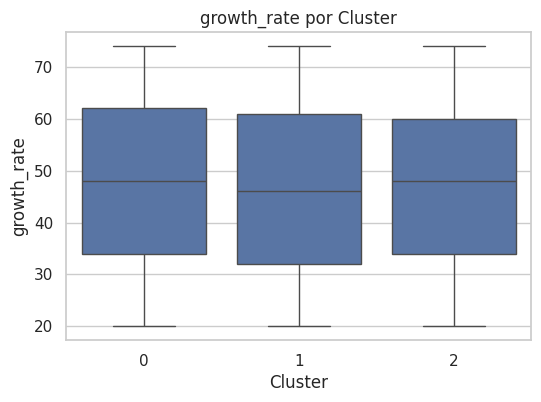

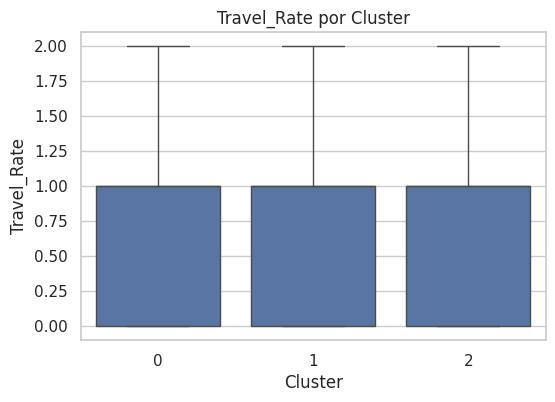

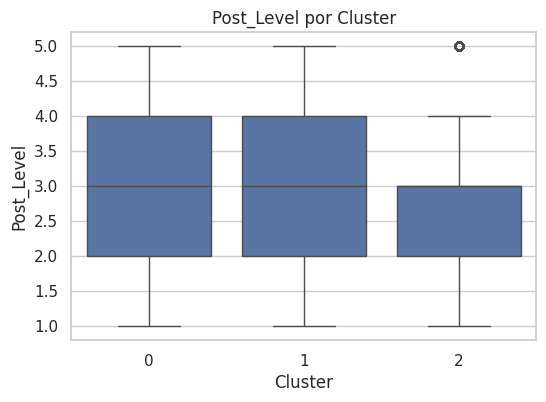

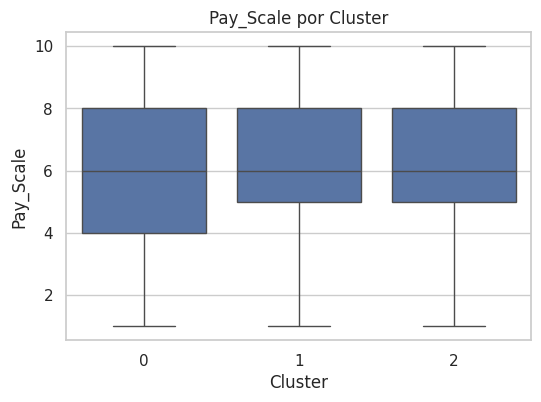

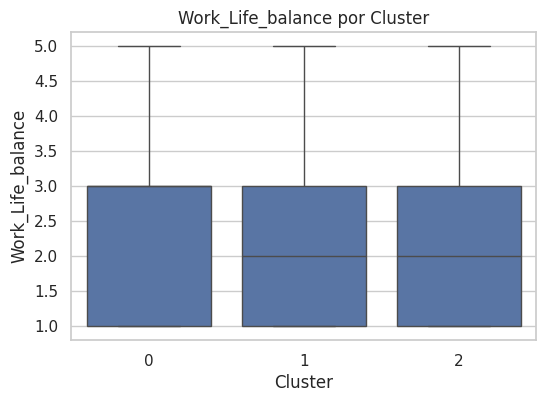

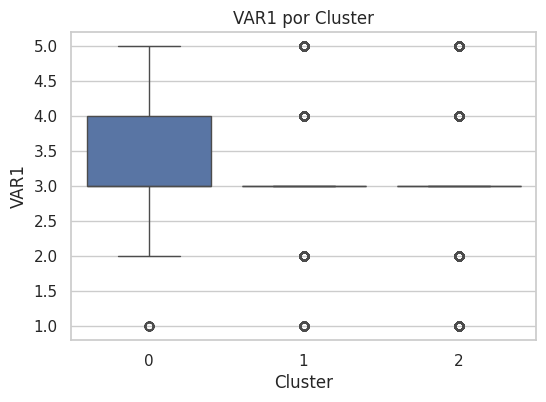

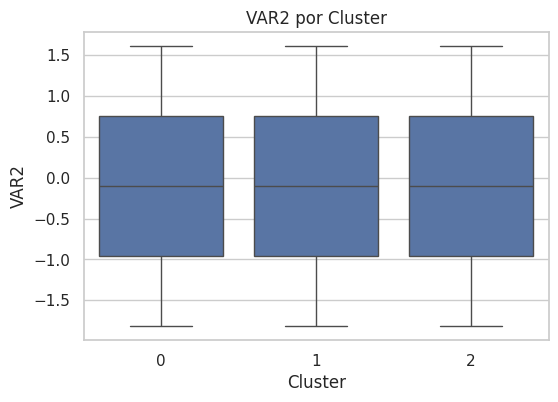

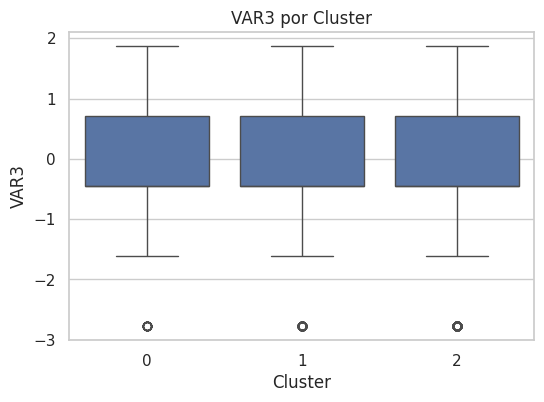

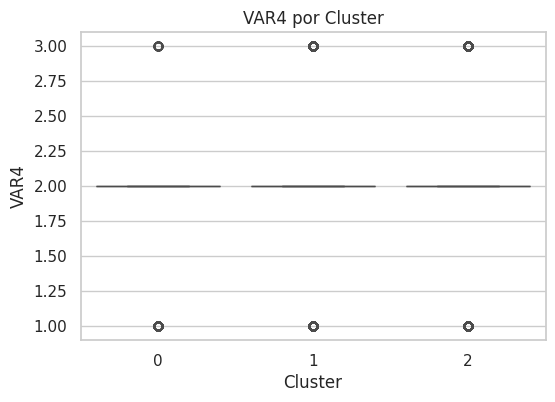

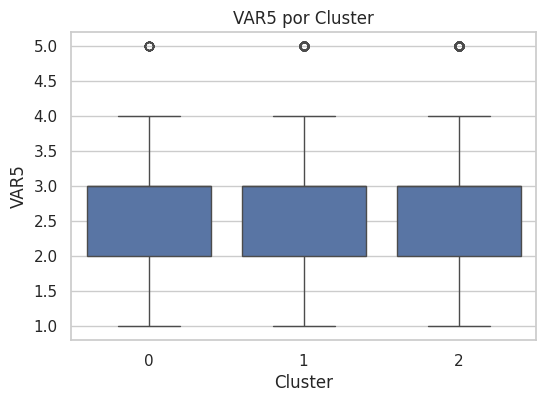

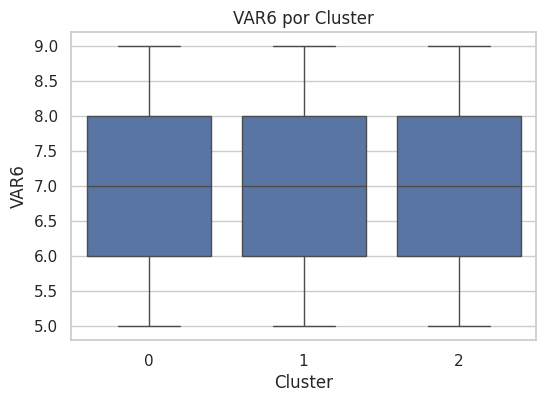

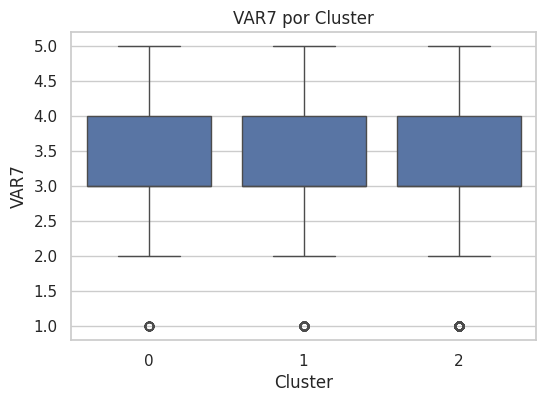

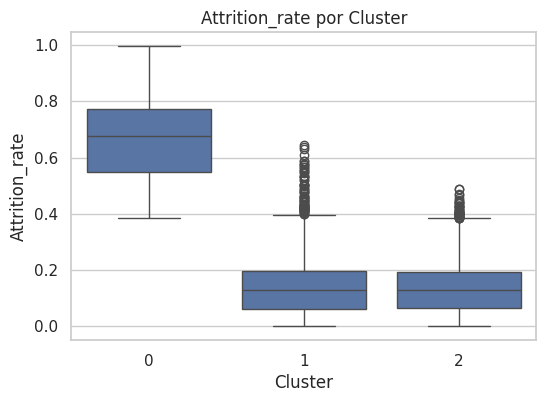

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Proceso terminado correctamente.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from google.colab import files

sns.set(style="whitegrid")

# ---------------------------
# 1. SUBIR CSV
# ---------------------------
print("Sube tu archivo CSV")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dimensiones:", df.shape)
display(df.head())

# ---------------------------
# 2. LIMPIEZA BÁSICA
# ---------------------------

for col in ['Employee_ID', 'ID', 'Id']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numéricas:", list(num_cols))
print("Categóricas:", list(cat_cols))

# ---------------------------
# 3. PREPROCESAMIENTO CON IMPUTACIÓN
# ---------------------------

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X = preprocessor.fit_transform(df)

print("Datos transformados:", X.shape)

# ---------------------------
# 4. ELBOW
# ---------------------------

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.title("Método Elbow")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.show()

# ---------------------------
# 5. SILHOUETTE
# ---------------------------

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Número de Clusters")
plt.ylabel("Score")
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print("Número óptimo de clusters:", optimal_k)

# ---------------------------
# 6. MODELO FINAL
# ---------------------------

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X)

display(df.head())

# ---------------------------
# 7. TABLA RESUMEN
# ---------------------------

summary = df.groupby('Cluster').mean(numeric_only=True)
display(summary)

# ---------------------------
# 8. VISUALIZACIONES
# ---------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data=df)
plt.title("Distribución de empleados por cluster")
plt.show()

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Cluster', y=col, data=df)
    plt.title(f"{col} por Cluster")
    plt.show()

# ---------------------------
# 9. EXPORTAR
# ---------------------------

df.to_csv("empleados_segmentados.csv", index=False)
files.download("empleados_segmentados.csv")

print("Proceso terminado correctamente.")


CONCLUSIONES:

Después de transformar las variables numéricas mediante estandarización y codificar las variables categóricas con OneHotEncoder, se aplicó el algoritmo K-Means probando distintos valores de K. Para seleccionar el número óptimo de grupos se utilizó el método Silhouette, el cual permitió evaluar la cohesión interna y separación entre clusters. El valor óptimo encontrado fue K = 3, ya que maximizó la calidad de segmentación.

A partir de la tabla resumen por cluster se identificaron tres perfiles claramente diferenciados dentro de la organización.

El Cluster 0 representa empleados en etapa intermedia de su carrera. Tienen una edad promedio cercana a los 38 años y una antigüedad aproximada de 11.7 años. Se encuentran en niveles salariales medios y con un balance vida-trabajo moderado. Este grupo parece estar en fase de consolidación profesional, por lo que podría beneficiarse de programas de desarrollo y planes de promoción a mediano plazo para fortalecer su compromiso y crecimiento dentro de la empresa.

El Cluster 1 agrupa empleados senior, con una edad promedio cercana a los 54 años y una antigüedad significativamente mayor, alrededor de 24.6 años. Presentan el mayor nivel salarial y mayor estabilidad laboral. Este grupo concentra experiencia crítica para la organización. Estratégicamente, la empresa podría implementar planes de sucesión, mentoría y transferencia de conocimiento para reducir riesgos asociados a posibles jubilaciones o salidas futuras.

El Cluster 2 corresponde a empleados jóvenes en etapas tempranas de su carrera, con una edad promedio de 30 años y menor tiempo de servicio (aproximadamente 6.4 años). Este grupo representa talento en crecimiento y potencial desarrollo. Resulta estratégico invertir en capacitación, planes de carrera estructurados e incentivos de retención temprana para maximizar su contribución futura.

En términos generales, la segmentación permitió identificar patrones claros relacionados con edad, antigüedad y nivel salarial, evidenciando ciclos naturales dentro de la trayectoria profesional de los empleados. Esta clasificación facilita la toma de decisiones estratégicas en recursos humanos, permitiendo diseñar políticas diferenciadas de compensación, desarrollo y retención según el perfil de cada grupo.

La aplicación de técnicas de transformación adecuadas y la validación del número óptimo de clusters garantizan que la segmentación sea consistente y útil para la toma de decisiones basada en datos.